# Prompts used for the code
Several ChatGPT prompts were used for the creation of this code and debugging.

The original prompt was along the lines of: "How can I read a pdf document and make training data for a LLM from it?". The next prompt asked the AI to give recommendations for layers using tensorflow.

This gave the base for the code, but several more propmts were using for debugging and fine-tuning the code to improve accuracy, for instance.

In [ ]:
# Tuodaan tiedosto jupyter notebookiin, kysytty AI:lta apua
from google.colab import files

uploaded = files.upload()

Saving Deep_Learning_with_Python_Second_Editio.pdf to Deep_Learning_with_Python_Second_Editio.pdf


In [ ]:
# Convertataan pdf-tiedosto tekstiksi
!pip install pdfplumber

import pdfplumber

file_path = "Deep_Learning_with_Python_Second_Editio.pdf"

text = ""

with pdfplumber.open(file_path) as pdf:
    for page in pdf.pages:
        text += page.extract_text() + "\n"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 106.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 125.2 MB/s eta 0:00:00


In [ ]:
# Puhdistetaan tekstiä
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)          # remove numbers
    text = re.sub(r'[^\w\s]', '', text)      # remove punctuation
    return text

cleaned_text = clean_text(text)

In [ ]:
# Ladataan tiktokenizer
!pip install tiktoken

In [ ]:
# Importataan tiktokenizer
import tiktoken

# Choose encoding (important!)
enc = tiktoken.get_encoding("cl100k_base")

In [ ]:
# Muutetaan teksti tokeneiksi
tokens = enc.encode(cleaned_text)

print("Total tokens:", len(tokens))

Total tokens: 211923


Overlap is used with chunks. According to chatgpt, this slightly improves the model.

In [ ]:
# Tehdään 100:n tokenin chunkeiksi, overlap käyttöön
def chunk_tokens_overlap(tokens, chunk_size=100, overlap=20):
    chunks = []

    for i in range(0, len(tokens), chunk_size - overlap):
        chunk = tokens[i:i + chunk_size]
        if len(chunk) == chunk_size:
            chunks.append(chunk)

    return chunks

token_chunks = chunk_tokens_overlap(tokens, 100, 20)
text_chunks = [enc.decode(chunk) for chunk in token_chunks]

print("Chunks with overlap:", len(text_chunks))

Chunks with overlap: 2648


In [ ]:
sequences = []

for chunk in token_chunks:
    input_seq = chunk[:-1]   # first 99 tokens
    target_seq = chunk[1:]   # shifted by 1

    sequences.append({
        "input": input_seq,
        "target": target_seq
    })

print("Total sequences:", len(sequences))

Total sequences: 2648


In [ ]:
# Tehdään 80/20 validaatiodata
import random
random.seed(42)

random.shuffle(sequences)

split_idx = int(len(sequences) * 0.8)

train_data = sequences[:split_idx]
val_data = sequences[split_idx:]

print("Train size:", len(train_data))
print("Validation size:", len(val_data))

Train size: 2118
Validation size: 530


In [ ]:
# Tallennetaan json:ksi
import json

with open("train.jsonl", "w") as f:
    for item in train_data:
        json.dump(item, f)
        f.write("\n")

with open("val.jsonl", "w") as f:
    for item in val_data:
        json.dump(item, f)
        f.write("\n")

# About JSON
Here we've made external json files. This ensures, that the training data itself can be brought to another environment, if necessary.

In [ ]:
# Ladataan JSONL datasetti
import numpy as np

def load_jsonl(file):
    data = []
    with open(file, "r") as f:
        for line in f:
            data.append(json.loads(line))
    return data

train_data = load_jsonl("train.jsonl")
val_data = load_jsonl("val.jsonl")

# Convert to numpy arrays
X_train = np.array([item["input"] for item in train_data])
y_train = np.array([item["target"] for item in train_data])

X_val = np.array([item["input"] for item in val_data])
y_val = np.array([item["target"] for item in val_data])

print(X_train.shape)  # (num_samples, 100)

(2118, 99)


In [ ]:
# Tehdään model
import tensorflow as tf
from tensorflow.keras import layers

#vocab_size = 100000  # safe default for cl100k_base
vocab_size = 20000  # or even 10000
seq_length = X_train.shape[1]

X_train = np.clip(X_train, 0, vocab_size - 1)
y_train = np.clip(y_train, 0, vocab_size - 1)

X_val = np.clip(X_val, 0, vocab_size - 1)
y_val = np.clip(y_val, 0, vocab_size - 1)

X_train = X_train.astype("int32")
y_train = y_train.astype("int32")
X_val = X_val.astype("int32")
y_val = y_val.astype("int32")

model = tf.keras.Sequential([
    #layers.Embedding(input_dim=vocab_size, output_dim=64, input_length=seq_length),
    #layers.Embedding(input_dim=vocab_size, output_dim=64),
    #layers.LSTM(128, return_sequences=True),
    # Lighter version
    layers.Embedding(input_dim=vocab_size, output_dim=32),
    layers.LSTM(64, return_sequences=True),
    layers.Dense(vocab_size, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.build(input_shape=(None, seq_length))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 99, 32)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 99, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 99, 20000)      │     1,300,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,964,832 (7.50 MB)

 Trainable params: 1,964,832 (7.50 MB)

 Non-trainable params: 0 (0.00 B)

#Training the model
Training the model takes approximately 18 minutes.

The accuracy is 11-12% and the loss is ~6%.

In [ ]:
# Koulutetaan model
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=32,
    epochs=5
)

Epoch 1/5
67/67 ━━━━━━━━━━━━━━━━━━━━ 206s 3s/step - accuracy: 0.0392 - loss: 8.1485 - val_accuracy: 0.0836 - val_loss: 6.2745
Epoch 2/5
67/67 ━━━━━━━━━━━━━━━━━━━━ 265s 3s/step - accuracy: 0.1179 - loss: 6.0861 - val_accuracy: 0.1178 - val_loss: 6.0537
Epoch 3/5
67/67 ━━━━━━━━━━━━━━━━━━━━ 214s 3s/step - accuracy: 0.1191 - loss: 6.0283 - val_accuracy: 0.1178 - val_loss: 6.0368
Epoch 4/5
67/67 ━━━━━━━━━━━━━━━━━━━━ 239s 3s/step - accuracy: 0.1191 - loss: 6.0140 - val_accuracy: 0.1178 - val_loss: 6.0301
Epoch 5/5
67/67 ━━━━━━━━━━━━━━━━━━━━ 206s 3s/step - accuracy: 0.1191 - loss: 6.0061 - val_accuracy: 0.1178 - val_loss: 6.0259


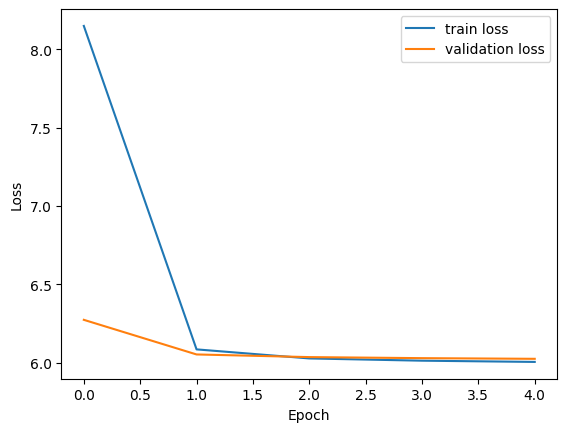

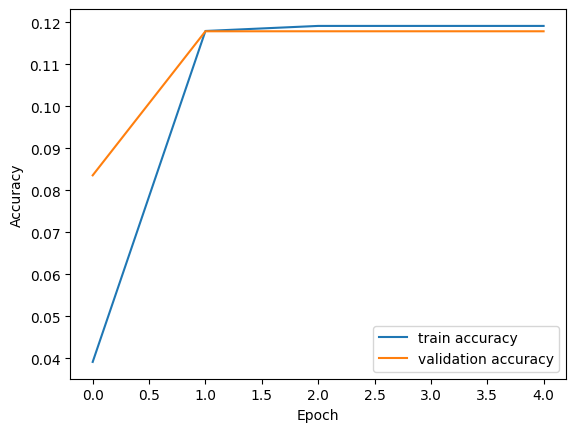

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
model.evaluate(X_val, y_val)

17/17 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.1178 - loss: 6.0259


[6.02590799331665, 0.11783876270055771]